In [13]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 43.8 MB/s eta 0:00:0000:0100:01


# 1. CAM, Grad-CAM용 모델 준비하기

In [14]:
import os
import shutil
import scipy.io as sio
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import cv2
import torch.nn.functional as F

import xml.etree.ElementTree as ET
from PIL import Image, ImageFile

ImageFile.LOAD_TRUNCATED_IMAGES = True

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# (1) 데이터셋 준비하기

In [4]:
!wget http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
!wget http://vision.stanford.edu/aditya86/ImageNetDogs/annotation.tar
!wget http://vision.stanford.edu/aditya86/ImageNetDogs/lists.tar
!tar -xf images.tar
!tar -xf annotation.tar
!tar -xf lists.tar

--2025-09-03 05:41:57--  http://vision.stanford.edu/aditya86/ImageNetDogs/images.tar
Resolving vision.stanford.edu (vision.stanford.edu)... 171.64.68.10
Connecting to vision.stanford.edu (vision.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 793579520 (757M) [application/x-tar]
Saving to: ‘images.tar’

images.tar          100%[===================>] 756.82M  24.5MB/s    in 63s     

2025-09-03 05:43:00 (12.0 MB/s) - ‘images.tar’ saved [793579520/793579520]

--2025-09-03 05:43:00--  http://vision.stanford.edu/aditya86/ImageNetDogs/annotation.tar
Resolving vision.stanford.edu (vision.stanford.edu)... 171.64.68.10
Connecting to vision.stanford.edu (vision.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 21852160 (21M) [application/x-tar]
Saving to: ‘annotation.tar’

annotation.tar      100%[===================>]  20.84M  4.92MB/s    in 6.7s    

2025-09-03 05:43:07 (3.13 MB/s) - ‘annotat

In [16]:
# 원본 데이터 경로 (압축 해제 후 폴더)
images_dir = 'Images'  # 이미지들이 위치한 폴더
mat_dir = ''  # 프로젝트 루트 디렉토리

# .mat 파일 경로 (train_list.mat와 test_list.mat가 각각 같은 구조라고 가정)
train_mat_path = os.path.join(mat_dir, 'train_list.mat')
test_mat_path = os.path.join(mat_dir, 'test_list.mat')

# .mat 파일 로드
train_mat = sio.loadmat(train_mat_path)
test_mat = sio.loadmat(test_mat_path)

# train_mat와 test_mat 내부에 'file_list'와 'labels' 등이 있음
train_file_list = train_mat['file_list']
train_labels = train_mat['labels'].squeeze()  # (N,)
test_file_list = test_mat['file_list']
test_labels = test_mat['labels'].squeeze()

# 최종적으로 ImageFolder 구조로 재구성할 대상 폴더 생성 (예: stanford_dogs/train, stanford_dogs/test)
base_dir = 'stanford_dogs'
train_dir = os.path.join(base_dir, 'train')
test_dir = os.path.join(base_dir, 'test')

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

def process_mat_file(file_list_array, split_dir):
    """
    .mat 파일에서 로드한 file_list_array를 사용해,
    split_dir(예: train 혹은 test)에 클래스별 폴더를 생성하고 이미지를 복사합니다.
    """
    num_files = file_list_array.shape[0]
    for idx in range(num_files):
        # file_list_array[idx]는 보통 array([<파일경로>]) 형태입니다.
        # 따라서, array([<파일경로>]).item()을 사용하면 실제 문자열을 얻을 수 있습니다.
        file_path = file_list_array[idx][0].item()

        # 혹시 bytes 타입이면 문자열로 디코딩
        if isinstance(file_path, bytes):
            file_path = file_path.decode('utf-8')

        # 파일 경로 예시: 'n02116738-African_hunting_dog/n02116738_2988.jpg'
        # 클래스 이름은 파일 경로의 최상위 폴더명 (예: 'n02116738-African_hunting_dog')
        class_folder = file_path.split('/')[0]

        # 대상 클래스 폴더 생성
        dest_folder = os.path.join(split_dir, class_folder)
        os.makedirs(dest_folder, exist_ok=True)

        # 원본 이미지 경로: Images 폴더 아래에 file_path 위치
        src_path = os.path.join(images_dir, file_path)
        # 대상 이미지 경로: dest_folder 아래에 원본 파일명 그대로 복사
        dest_path = os.path.join(dest_folder, os.path.basename(file_path))

        # 파일 존재 여부 확인 후 복사
        if os.path.exists(src_path):
            shutil.copy(src_path, dest_path)
        else:
            print(f"File not found: {src_path}")

print("Processing train set...")
process_mat_file(train_file_list, train_dir)
print("Processing test set...")
process_mat_file(test_file_list, test_dir)

print("Dataset reorganization complete.")

Processing train set...
Processing test set...
Dataset reorganization complete.


In [17]:
class StanfordDogsDatasetWithBBox(datasets.ImageFolder):
    def __init__(self, root, annotation_root, transform=None):
        super().__init__(root, transform=transform)
        self.annotation_root = annotation_root  # 예: '/content/Annotation'
        self.new_size = (224, 224)

    def __getitem__(self, index):
        image, label = super().__getitem__(index)
        path, _ = self.samples[index]

        rel_path = os.path.relpath(path, self.root)
        annot_filename = os.path.splitext(os.path.basename(rel_path))[0]
        annot_folder = os.path.dirname(rel_path)
        annot_path = os.path.join(self.annotation_root, annot_folder, annot_filename)

        # bbox 기본값 (예: [ymin, xmin, ymax, xmax])
        bbox = [0.0, 0.0, 0.0, 0.0]

        if os.path.exists(annot_path):
            try:
                # 확장자가 없지만 XML 형식의 파일이라고 가정하고 파싱
                tree = ET.parse(annot_path)
                root_xml = tree.getroot()
                # 첫 번째 object 태그에서 bndbox 정보를 읽음
                obj = root_xml.find('object')
                if obj is not None:
                    bndbox = obj.find('bndbox')
                    if bndbox is not None:
                        xmin = float(bndbox.find('xmin').text)
                        ymin = float(bndbox.find('ymin').text)
                        xmax = float(bndbox.find('xmax').text)
                        ymax = float(bndbox.find('ymax').text)
                        # XML 내 <size> 태그에서 원본 이미지 크기 획득
                        size = root_xml.find('size')
                        w = float(size.find('width').text)
                        h = float(size.find('height').text)
                        new_h, new_w = self.new_size
                        # bbox 좌표 순서: [ymin, xmin, ymax, xmax]
                        bbox = [xmin * (new_w / w), ymin * (new_h / h),
                                xmax * (new_w / w), ymax * (new_h / h)]
                    else:
                        print(f"bndbox 태그를 찾을 수 없습니다: {annot_path}")
                else:
                    print(f"object 태그를 찾을 수 없습니다: {annot_path}")
            except Exception as e:
                print(f"Error parsing {annot_path}: {e}")
        else:
            print(f"Annotation file not found: {annot_path}")

        return image, label, bbox

In [18]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# 데이터셋 경로 (재구성한 ImageFolder 형식)
train_dir = os.path.join('stanford_dogs', 'train')
test_dir = os.path.join('stanford_dogs', 'test')
# Annotation 폴더 경로 (예: '/root/Annotation')
annotation_dir = 'Annotation'

# 커스텀 데이터셋 생성: image, label, bbox 반환
train_dataset = StanfordDogsDatasetWithBBox(root=train_dir, annotation_root=annotation_dir, transform=transform)
valid_dataset = StanfordDogsDatasetWithBBox(root=test_dir, annotation_root=annotation_dir, transform=transform)

batch_size = 12
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

num_classes = len(train_dataset.classes)
print(f"Number of classes: {num_classes}")
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(valid_dataset)}")

Number of classes: 120
Train samples: 12000
Test samples: 8580


In [19]:
def visualize(sample):
    img_tensor, label, bbox = sample

    # 인덱스와 클래스 정보
    print("Label index:", label)
    print("Class name:", train_dataset.classes[label])

    # 정규화 복원 전처리 시 사용한 평균과 표준편차
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    # tensor의 shape: (C, H, W) -> (H, W, C)
    img_np = img_tensor.permute(1, 2, 0).numpy()
    img_np = std * img_np + mean
    img_np = np.clip(img_np, 0, 1)

    plt.figure(figsize=(6,6))
    plt.imshow(img_np)
    plt.title(f"Class: {train_dataset.classes[label]}")
    plt.axis('off')
    plt.show()

Label index: 0
Class name: n02085620-Chihuahua


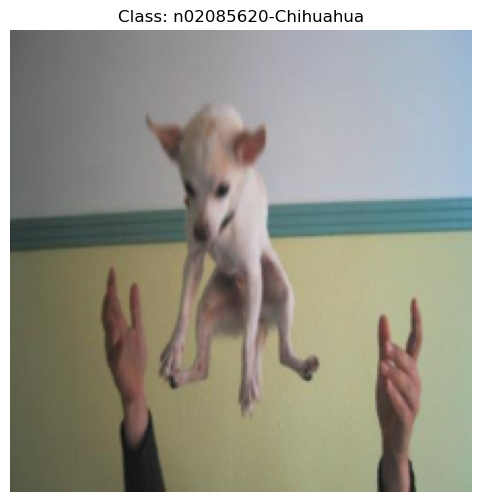

In [20]:
# 임의의 한 샘플 선택 (여기서는 첫 번째 샘플을 사용)
train_sample = train_dataset[0]

visualize(train_sample)

Label index: 0
Class name: n02085620-Chihuahua


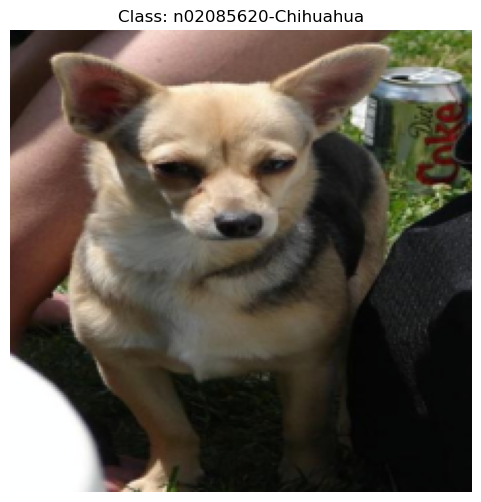

In [21]:
# 임의의 한 샘플 선택 (여기서는 첫 번째 샘플을 사용)
test_sample = valid_dataset[0]

visualize(test_sample)

# (2) 물체의 위치정보

In [22]:
# Annotation 폴더에서 데이터를 골라보세요
annotation_path = 'Annotation/n02085620-Chihuahua/n02085620_10074'


# XML 파일 파싱
tree = ET.parse(annotation_path)
root = tree.getroot()

for elem in root.iter():
    print(f"{elem.tag}: {elem.text}")

annotation: 
	
folder: 02085620
filename: n02085620_10074
source: 
		
database: ImageNet database
size: 
		
width: 333
height: 500
depth: 3
segment: 0
object: 
		
name: Chihuahua
pose: Unspecified
truncated: 0
difficult: 0
bndbox: 
			
xmin: 25
ymin: 10
xmax: 276
ymax: 498


# (3) CAM을 위한 모델 만들기

In [26]:
import torch
import torch.nn as nn
from torchvision import models

# 1) 사전학습된 ResNet-50 불러오기
model_grad = models.resnet50(pretrained=True)
model_cam = models.resnet50(pretrained=True)

# 2) FC(마지막 분류기)만 데이터셋 클래스 수에 맞게 교체
num_ftrs = model_cam.fc.in_features
model_cam.fc = nn.Linear(num_ftrs, len(train_dataset.classes))

# 3) Grad-CAM 추론 편의를 위해 Softmax를 뒤에 덧붙인 래퍼 모델 구성
#    - ResNet: [.. → avgpool → fc] 까지 로짓 생성
#    - Softmax: 클래스 확률 (Grad-CAM 시 종종 확률/로짓 중 선택해 사용)
gradcam_model = nn.Sequential(
    model_cam,
    nn.Softmax(dim=1)  # pooling(fc) 뒤에 소프트맥스
).to(device)

In [27]:
model_cam

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [28]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_cam.parameters(), lr=0.01, momentum=0.9)

In [29]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, num_epochs=2):
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        print(f"\nEpoch {epoch+1}/{num_epochs} 시작")
        for batch_idx, (images, labels, _) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            if (batch_idx + 1) % 50 == 0:
                print(f"  Step {batch_idx+1} - Loss: {loss.item():.4f}")

        train_loss = running_loss / (batch_idx + 1)
        train_acc = correct / total
        print(f"Train - Loss: {train_loss:.4f}, Accuracy: {train_acc*100:.2f}%")

        # 검증 단계
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels, _ in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()
        test_loss = running_loss / len(valid_loader)
        test_acc = correct / total
        print(f"Validation - Loss: {test_loss:.4f}, Accuracy: {test_acc*100:.2f}%")

In [70]:
%%time

train_model(model_cam, train_loader, valid_loader, criterion, optimizer, num_epochs=5)


Epoch 1/5 시작
  Step 50 - Loss: 4.2956
  Step 100 - Loss: 3.3766
  Step 150 - Loss: 4.3633
  Step 200 - Loss: 3.2179
  Step 250 - Loss: 3.8789
  Step 300 - Loss: 3.0672
  Step 350 - Loss: 2.7358
  Step 400 - Loss: 2.9370
  Step 450 - Loss: 3.5767
  Step 500 - Loss: 3.3342
  Step 550 - Loss: 3.4208
  Step 600 - Loss: 3.0657
  Step 650 - Loss: 2.4499
  Step 700 - Loss: 3.7414
  Step 750 - Loss: 2.0160
  Step 800 - Loss: 2.7013
  Step 850 - Loss: 2.5497
  Step 900 - Loss: 3.3801
  Step 950 - Loss: 2.7201
  Step 1000 - Loss: 2.3767
Train - Loss: 3.1523, Accuracy: 22.94%
Validation - Loss: 3.0786, Accuracy: 28.21%

Epoch 2/5 시작
  Step 50 - Loss: 2.0837
  Step 100 - Loss: 2.9454
  Step 150 - Loss: 3.1082
  Step 200 - Loss: 2.0300
  Step 250 - Loss: 2.1772
  Step 300 - Loss: 1.1408
  Step 350 - Loss: 2.3318
  Step 400 - Loss: 1.9608
  Step 450 - Loss: 2.2068
  Step 500 - Loss: 1.7840
  Step 550 - Loss: 2.2952
  Step 600 - Loss: 1.8332
  Step 650 - Loss: 3.1707
  Step 700 - Loss: 1.4874
  Step

In [71]:
cam_model_path = "cam_model.pt"

torch.save(model_cam, cam_model_path)

# 2. CAM

In [72]:
def unnormalize(img_tensor):
    """
    img_tensor: [C, H, W] 텐서 (전처리 상태, 예: normalization 적용됨)
    ImageNet 평균 및 표준편차를 이용하여 복원 (RGB 순서)
    """
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = img_tensor.cpu().numpy().transpose(1, 2, 0)
    img = std * img + mean
    img = np.clip(img, 0, 1)
    img = np.uint8(255 * img)
    return img

In [73]:
# 원하는 데이터를 골라서 진행해보세요

image, label, bbox = train_dataset[0]
sample_image = image.unsqueeze(0).to(device)

In [74]:
model_cam = torch.load(cam_model_path, weights_only=False)

In [75]:
def generate_cam(model, image):
    model.eval()
    features = []

    def hook(module, input, output):
        features.append(output.detach())
    hook_handle = model.layer4.register_forward_hook(hook)

    output = model(image)
    hook_handle.remove()

    # 예측된 클래스 선택 (배치의 첫 번째 이미지 기준)
    pred_class = output.argmax(dim=1).item()

    # 모델의 fc layer 가중치가 모델과 동일한 디바이스에 있도록 처리
    fc_weights = model.fc.weight.data.to(image.device)

    # features[0]: shape [1, num_features, H, W]
    fmap = features[0][0]  # 첫 번째 이미지의 feature map
    cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=image.device)

    # fc 가중치와 feature map의 각 채널을 가중합
    for i, w in enumerate(fc_weights[pred_class]):
        cam += w * fmap[i, :, :]
    cam = cam.cpu().numpy()

    # CAM 정규화
    cam = np.maximum(cam, 0)
    cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam) + 1e-8)

    return cam

In [76]:
cam = generate_cam(model_cam, sample_image)

In [77]:
def visualize_cam(cam):
    plt.imshow(cam, cmap='jet')
    plt.colorbar()
    plt.title("CAM")
    plt.axis('off')
    plt.show()

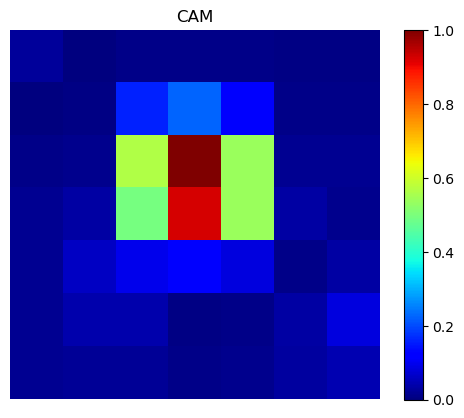

In [78]:
visualize_cam(cam)

In [79]:
def visualize_cam_on_image(cam, img, alpha=0.5):
    # CAM 크기를 원본 이미지 크기로 조정
    cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))

    # CAM을 컬러 heatmap으로 변환 (cv2.applyColorMap는 BGR로 반환하므로 RGB로 변경)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # 원본 이미지와 heatmap을 alpha blending
    overlay = heatmap * alpha + img * (1 - alpha)
    overlay = overlay.astype(np.uint8)

    plt.figure(figsize=(8,8))
    plt.imshow(overlay)
    plt.title("CAM Overlay on Image")
    plt.axis('off')
    plt.show()

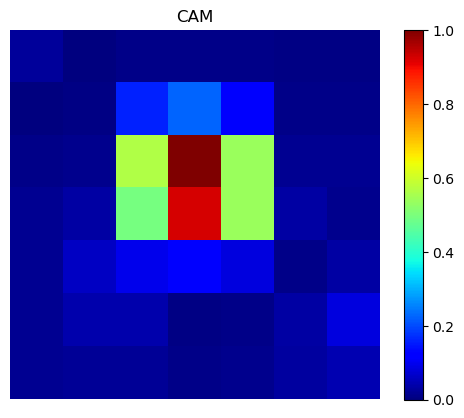

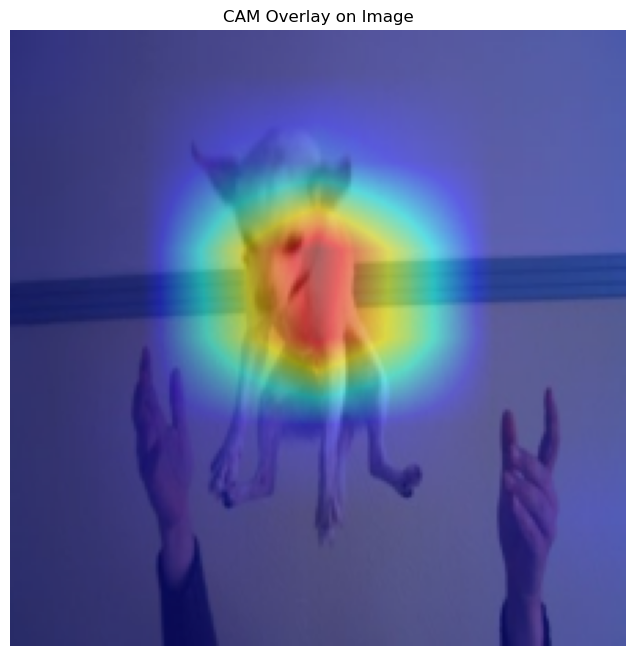

In [80]:
# 원본 이미지 복원
orig_img = unnormalize(image)

# CAM 단독 시각화
visualize_cam(cam)

# 원본 이미지 위에 CAM overlay 시각화
visualize_cam_on_image(cam, orig_img)

# 3. Grad-CAM

In [44]:
# 원하는 데이터를 골라서 진행해보세요

image, label, bbox = train_dataset[0]
sample_image = image.unsqueeze(0).to(device)

In [81]:
def generate_grad_cam(model, image, target_layer_name):
    model.eval()
    features = {}
    gradients = {}

    # forward hook: 대상 레이어의 출력을 저장
    def forward_hook(module, input, output):
        features['value'] = output.detach()

    # backward hook: 대상 레이어의 gradient를 저장
    def backward_hook(module, grad_in, grad_out):
        gradients['value'] = grad_out[0].detach()

    # 모델 내에서 이름이 target_layer_name과 일치하는 레이어 검색
    target_layer = dict(model.named_modules()).get(target_layer_name, None)
    if target_layer is None:
        raise ValueError(f"Layer '{target_layer_name}' not found in the model.")

    # hook 등록
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_backward_hook(backward_hook)

    # 순전파 실행
    output = model(image)
    pred_class = output.argmax(dim=1).item()

    # 예측 클래스에 대해 backward 수행
    model.zero_grad()
    score = output[0, pred_class]
    score.backward()

    # hook 제거
    forward_handle.remove()
    backward_handle.remove()

    # 저장된 feature map과 gradient 추출 (shape: [C, H, W])
    fmap = features['value'][0]
    grads = gradients['value'][0]

    # 각 채널에 대해 gradient의 global average pooling 계산 (weight 역할)
    weights = torch.mean(grads, dim=(1, 2))

    # weighted sum: 각 채널의 feature map에 weight를 곱해 합산
    grad_cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=fmap.device)
    for i, w in enumerate(weights):
        grad_cam += w * fmap[i, :, :]
    grad_cam = grad_cam.cpu().numpy()

    # ReLU 적용 및 정규화: 음수 값 제거 및 [0,1] 범위로 스케일링
    grad_cam = np.maximum(grad_cam, 0)
    grad_cam = (grad_cam - grad_cam.min()) / (grad_cam.max() - grad_cam.min() + 1e-8)

    return grad_cam

In [82]:
# layer4 사용
grad_cam = generate_grad_cam(model_grad, sample_image, target_layer_name="layer4")

# Grad-CAM 단독 시각화
visualize_cam(grad_cam)

# 전처리된 이미지를 원본 이미지로 복원 후 overlay 시각화
orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

In [ ]:
grad_cam = generate_grad_cam(model_grad, sample_image, target_layer_name="layer1")

# Grad-CAM 단독 시각화
visualize_cam(grad_cam)

# 전처리된 이미지를 원본 이미지로 복원 후 overlay 시각화
orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

In [ ]:
grad_cam = generate_grad_cam(model_grad, sample_image, target_layer_name="layer2")

# Grad-CAM 단독 시각화
visualize_cam(grad_cam)

# 전처리된 이미지를 원본 이미지로 복원 후 overlay 시각화
orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

In [ ]:
grad_cam = generate_grad_cam(model_grad, sample_image, target_layer_name="layer3")

# Grad-CAM 단독 시각화
visualize_cam(grad_cam)

# 전처리된 이미지를 원본 이미지로 복원 후 overlay 시각화
orig_img = unnormalize(image)
visualize_cam_on_image(grad_cam, orig_img)

# 4. Detection with CAM

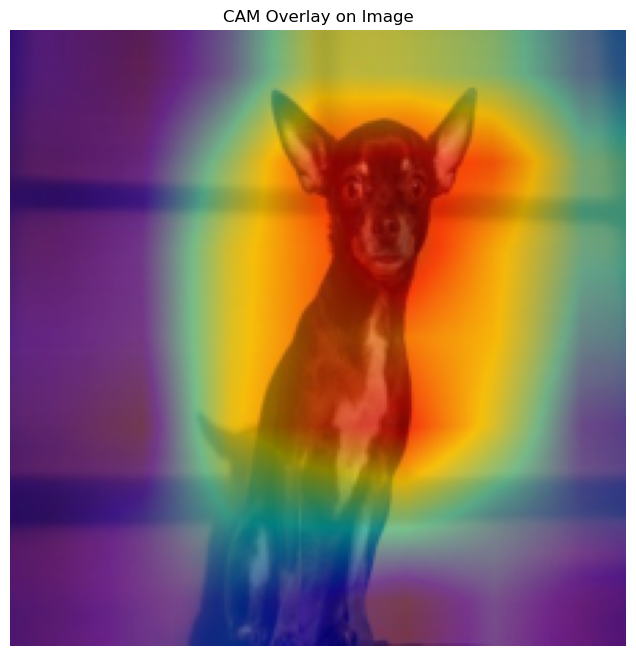

In [50]:
image, label, ground_bbox = train_dataset[10]
sample_image = image.unsqueeze(0).to(device)
orig_img = unnormalize(image)
grad_cam = generate_grad_cam(model, sample_image, target_layer_name="layer4")

visualize_cam_on_image(grad_cam, orig_img)

In [51]:
def get_bbox(cam, threshold=0.01):
    coords = np.argwhere(cam > threshold)
    if coords.size == 0:
        return None
    # np.argwhere의 결과는 (row, col) 즉, (y, x) 순서입니다.
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    return (x_min, y_min, x_max, y_max)

In [52]:
cam_resized = cv2.resize(cam, (orig_img.shape[1], orig_img.shape[0]))
bbox = get_bbox(cam_resized, threshold=0.3)

print(bbox)

(np.int64(54), np.int64(67), np.int64(189), np.int64(223))


In [53]:
def visualize_bbox_on_image(img, bbox, box_color=(255, 0, 0), thickness=2):
    # 원본 이미지 복사
    img_with_bbox = img.copy()
    if bbox is not None:
        x_min, y_min, x_max, y_max = bbox
        cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), box_color, thickness)
    else:
        print("활성화된 영역이 없습니다.")
    return img_with_bbox

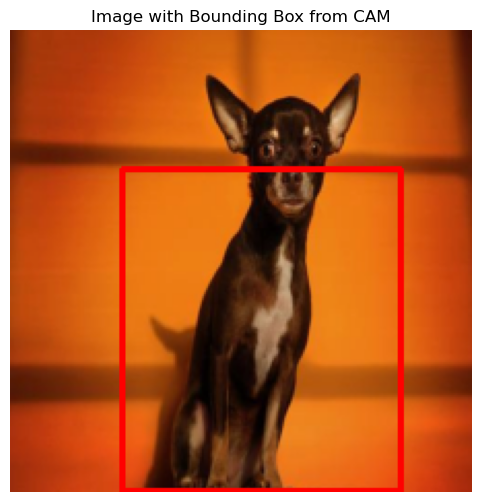

In [54]:
img_bbox = visualize_bbox_on_image(orig_img, bbox)

plt.figure(figsize=(6,6))
plt.imshow(img_bbox)
plt.title("Image with Bounding Box from CAM")
plt.axis("off")
plt.show()

In [55]:
ground_bbox

[78.848, 19.333333333333332, 169.792, 222.0]

In [56]:
def get_iou(bbox1, bbox2):
    # bbox 중 하나라도 None이면 IoU 0.0
    if bbox1 is None or bbox2 is None:
        return 0.0

    x_min1, y_min1, x_max1, y_max1 = bbox1
    x_min2, y_min2, x_max2, y_max2 = bbox2

    # 두 bbox의 교집합 영역 좌표 계산
    x_min_inter = max(x_min1, x_min2)
    y_min_inter = max(y_min1, y_min2)
    x_max_inter = min(x_max1, x_max2)
    y_max_inter = min(y_max1, y_max2)

    # 교집합의 너비와 높이 (음수가 되지 않도록)
    inter_width = max(0, x_max_inter - x_min_inter)
    inter_height = max(0, y_max_inter - y_min_inter)
    inter_area = inter_width * inter_height

    # 각 bbox의 면적 계산
    area1 = (x_max1 - x_min1) * (y_max1 - y_min1)
    area2 = (x_max2 - x_min2) * (y_max2 - y_min2)

    # 합집합 면적: A ∪ B = A + B - A ∩ B
    union_area = area1 + area2 - inter_area
    if union_area <= 0:
        return 0.0

    iou = inter_area / union_area
    return iou

In [57]:
get_iou(bbox, ground_bbox)

np.float64(0.5550825548422975)

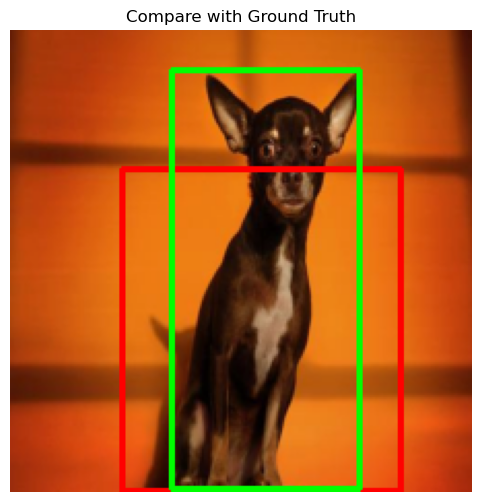

In [58]:
def visualize_both_bbox_on_image(img, bbox, ground_truth, thickness=2):
    # 원본 이미지 복사
    img_with_bbox = img.copy()

    x_min, y_min, x_max, y_max = bbox
    cv2.rectangle(img_with_bbox, (x_min, y_min), (x_max, y_max), (255, 0, 0), thickness)

    x_min_t, y_min_t, x_max_t, y_max_t = ground_truth
    cv2.rectangle(img_with_bbox, (x_min_t, y_min_t), (x_max_t, y_max_t), (0, 255, 0), thickness)

    return img_with_bbox

ground_truth = [int(x) for x in ground_bbox]

img_bbox = visualize_both_bbox_on_image(orig_img, bbox, ground_truth)

plt.figure(figsize=(6,6))
plt.imshow(img_bbox)
plt.title("Compare with Ground Truth")
plt.axis("off")
plt.show()

# 프로젝트: CAM을 만들고 평가해 보자

In [59]:
import torch
import numpy as np
import cv2
import PIL

print(torch.__version__)
print(np.__version__)
print(cv2.__version__)
print(PIL.__version__)

2.7.1+cu118
2.2.6
4.12.0
11.2.1


In [60]:
def generate_cam(model, image):
    model.eval()
    features = []

    def hook(module, input, output):
        features.append(output.detach())
    hook_handle = model.layer4.register_forward_hook(hook)

    output = model(image)
    hook_handle.remove()

    # 예측된 클래스 선택 (배치의 첫 번째 이미지 기준)
    pred_class = output.argmax(dim=1).item()

    # 모델의 fc layer 가중치가 모델과 동일한 디바이스에 있도록 처리
    fc_weights = model.fc.weight.data.to(image.device)

    # features[0]: shape [1, num_features, H, W]
    fmap = features[0][0]  # 첫 번째 이미지의 feature map
    cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=image.device)

    # fc 가중치와 feature map의 각 채널을 가중합
    for i, w in enumerate(fc_weights[pred_class]):
        cam += w * fmap[i, :, :]
    cam = cam.cpu().numpy()

    # CAM 정규화
    cam = np.maximum(cam, 0)
    cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam) + 1e-8)

    return cam

In [61]:
cam = generate_cam(model, sample_image)

In [62]:
def visualize_cam_on_image(cam, img, alpha=0.5):
    # CAM 크기를 원본 이미지 크기로 조정
    cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))

    # CAM을 컬러 heatmap으로 변환 (cv2.applyColorMap는 BGR로 반환하므로 RGB로 변경)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # 원본 이미지와 heatmap을 alpha blending
    overlay = heatmap * alpha + img * (1 - alpha)
    overlay = overlay.astype(np.uint8)

    plt.figure(figsize=(8,8))
    plt.imshow(overlay)
    plt.title("CAM Overlay on Image")
    plt.axis('off')
    plt.show()

In [63]:
def generate_grad_cam(model, image, target_layer_name):
    model.eval()
    features = {}
    gradients = {}

    # forward hook: 대상 레이어의 출력을 저장
    def forward_hook(module, input, output):
        features['value'] = output.detach()

    # backward hook: 대상 레이어의 gradient를 저장
    def backward_hook(module, grad_in, grad_out):
        gradients['value'] = grad_out[0].detach()

    # 모델 내에서 이름이 target_layer_name과 일치하는 레이어 검색
    target_layer = dict(model.named_modules()).get(target_layer_name, None)
    if target_layer is None:
        raise ValueError(f"Layer '{target_layer_name}' not found in the model.")

    # hook 등록
    forward_handle = target_layer.register_forward_hook(forward_hook)
    backward_handle = target_layer.register_backward_hook(backward_hook)

    # 순전파 실행
    output = model(image)
    pred_class = output.argmax(dim=1).item()

    # 예측 클래스에 대해 backward 수행
    model.zero_grad()
    score = output[0, pred_class]
    score.backward()

    # hook 제거
    forward_handle.remove()
    backward_handle.remove()

    # 저장된 feature map과 gradient 추출 (shape: [C, H, W])
    fmap = features['value'][0]
    grads = gradients['value'][0]

    # 각 채널에 대해 gradient의 global average pooling 계산 (weight 역할)
    weights = torch.mean(grads, dim=(1, 2))

    # weighted sum: 각 채널의 feature map에 weight를 곱해 합산
    grad_cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=fmap.device)
    for i, w in enumerate(weights):
        grad_cam += w * fmap[i, :, :]
    grad_cam = grad_cam.cpu().numpy()

    # ReLU 적용 및 정규화: 음수 값 제거 및 [0,1] 범위로 스케일링
    grad_cam = np.maximum(grad_cam, 0)
    grad_cam = (grad_cam - grad_cam.min()) / (grad_cam.max() - grad_cam.min() + 1e-8)

    return grad_cam

In [64]:
def get_iou(bbox1, bbox2):
    # bbox 중 하나라도 None이면 IoU 0.0
    if bbox1 is None or bbox2 is None:
        return 0.0

    x_min1, y_min1, x_max1, y_max1 = bbox1
    x_min2, y_min2, x_max2, y_max2 = bbox2

    # 두 bbox의 교집합 영역 좌표 계산
    x_min_inter = max(x_min1, x_min2)
    y_min_inter = max(y_min1, y_min2)
    x_max_inter = min(x_max1, x_max2)
    y_max_inter = min(y_max1, y_max2)

    # 교집합의 너비와 높이 (음수가 되지 않도록)
    inter_width = max(0, x_max_inter - x_min_inter)
    inter_height = max(0, y_max_inter - y_min_inter)
    inter_area = inter_width * inter_height

    # 각 bbox의 면적 계산
    area1 = (x_max1 - x_min1) * (y_max1 - y_min1)
    area2 = (x_max2 - x_min2) * (y_max2 - y_min2)

    # 합집합 면적: A ∪ B = A + B - A ∩ B
    union_area = area1 + area2 - inter_area
    if union_area <= 0:
        return 0.0

    iou = inter_area / union_area
    return iou

In [65]:
for images, labels, bboxes in EVAL_LOADER:
    print(type(bboxes), getattr(bboxes, 'shape', None))
    print("sample bbox raw:", (bboxes[0].detach().cpu().numpy() if torch.is_tensor(bboxes) else bboxes[0]))
    break

NameError: name 'EVAL_LOADER' is not defined

2.7.1+cu118
2.2.6
4.12.0
11.2.1


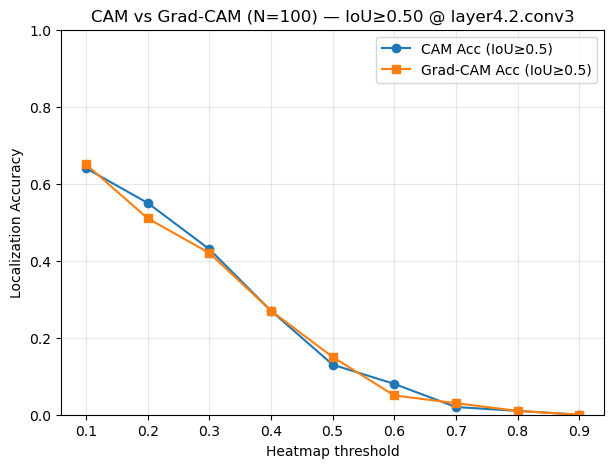

Thresholds: [np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9)]
CAM Acc   : ['0.640', '0.550', '0.430', '0.270', '0.130', '0.080', '0.020', '0.010', '0.000']
Grad Acc  : ['0.650', '0.510', '0.420', '0.270', '0.150', '0.050', '0.030', '0.010', '0.000']


In [69]:
# ============================================================
# Versions
# ============================================================
import torch
import numpy as np
import cv2
import PIL

print(torch.__version__)
print(np.__version__)
print(cv2.__version__)
print(PIL.__version__)

# ============================================================
# CAM (uses GAP + FC weights of the trained model)
# ============================================================
def generate_cam(model, image):
    model.eval()
    features = []

    def hook(module, input, output):
        features.append(output.detach())
    hook_handle = model.layer4.register_forward_hook(hook)

    output = model(image)
    hook_handle.remove()

    # 예측된 클래스 선택 (배치의 첫 번째 이미지 기준)
    pred_class = output.argmax(dim=1).item()

    # 모델의 fc layer 가중치 (image와 같은 디바이스)
    fc_weights = model.fc.weight.data.to(image.device)

    # features[0]: shape [1, C, h, w]
    fmap = features[0][0]  # (C,h,w)
    cam = torch.zeros(fmap.shape[1:], dtype=torch.float32, device=image.device)

    # fc 가중치와 feature map의 각 채널을 가중합
    for i, w in enumerate(fc_weights[pred_class]):
        cam += w * fmap[i, :, :]

    cam = cam.cpu().numpy()

    # CAM 정규화
    cam = np.maximum(cam, 0)
    cam = (cam - np.min(cam)) / (np.max(cam) - np.min(cam) + 1e-8)
    return cam

# ============================================================
# (Optional) 시각화 유틸
# ============================================================
import matplotlib.pyplot as plt

def visualize_cam_on_image(cam, img, alpha=0.5):
    # CAM 크기를 원본 이미지 크기로 조정
    cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))

    # CAM을 컬러 heatmap으로 변환 (cv2.applyColorMap는 BGR로 반환하므로 RGB로 변경)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    # 원본 이미지와 heatmap을 alpha blending
    overlay = heatmap * alpha + img * (1 - alpha)
    overlay = overlay.astype(np.uint8)

    plt.figure(figsize=(8,8))
    plt.imshow(overlay)
    plt.title("CAM Overlay on Image")
    plt.axis('off')
    plt.show()

# ============================================================
# Grad-CAM (original model as-is; logits backward; no Softmax)
# ============================================================
import torch.nn.functional as F

def generate_grad_cam(model, image, target_layer_name: str = "layer4.2.conv3"):
    """
    model: 학습 완료된 '원본' 분류 모델 (Softmax 없이)
    image: (1,C,H,W) 텐서, 전처리 완료 & model과 같은 device
    target_layer_name: 예) 'layer4', 'layer4.2', 'layer4.2.conv3' (권장)
    반환: (h,w) in [0,1]
    """
    model.eval()
    model.zero_grad(set_to_none=True)

    # 타깃 레이어 찾기
    # (ResNet-50에서는 'layer4.2.conv3'가 마지막 컨브)
    target_layer = dict(model.named_modules()).get(target_layer_name, None)
    if target_layer is None:
        raise ValueError(f"Layer '{target_layer_name}' not found in the model.")

    acts, grads = {}, {}

    def fwd_hook(_m, _inp, out):
        acts["v"] = out  # (B,C,h,w)

    def bwd_hook(_m, grad_input, grad_output):
        grads["v"] = grad_output[0]  # (B,C,h,w)

    h1 = target_layer.register_forward_hook(fwd_hook)
    # 최신 API 권장
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    with torch.enable_grad():
        logits = model(image)                          # 로짓 (Softmax X)
        pred_class = int(logits.argmax(dim=1).item())
        score = logits[:, pred_class].sum()

    score.backward()
    h1.remove(); h2.remove()

    fmap = acts["v"][0]     # (C,h,w)
    gmap = grads["v"][0]    # (C,h,w)

    # 채널 중요도: 공간 평균 grad
    weights = gmap.mean(dim=(1, 2))           # (C,)

    # 가중합 (벡터화)
    cam = (weights[:, None, None] * fmap).sum(dim=0)   # (h,w)
    cam = F.relu(cam)

    cam = cam.detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam

# ============================================================
# 보조 유틸들 (unnorm, bbox 변환/IoU 등)
# ============================================================
from typing import Optional

def _unnorm_fallback(img_t: torch.Tensor) -> np.ndarray:
    x = img_t.detach().cpu()
    if x.dim() == 3:
        x = x.permute(1,2,0)  # [H,W,C]
    x = (x * 0.5 + 0.5).clamp(0,1)  # 기본(mean=0.5,std=0.5) 역정규화 가정
    return (x.numpy() * 255).astype(np.uint8)

def _unnorm(img_t: torch.Tensor) -> np.ndarray:
    if 'unnormalize' in globals():
        return unnormalize(img_t)
    return _unnorm_fallback(img_t)

def to_xyxy_pixels_minmax(bbox, W: int, H: int, strategy: str = 'union') -> Optional[np.ndarray]:
    """
    bbox: 길이 4 또는 4*k 벡터/리스트/텐서 (각 4원소는 [ymin, xmin, ymax, xmax])
          값이 0~1이면 정규화로 간주하여 (H,W)로 스케일
    반환: 단일 [x1,y1,x2,y2] 픽셀 좌표
          strategy='union'  : 모든 박스의 외접 박스
          strategy='largest': 가장 큰 면적 박스
    """
    if bbox is None:
        return None
    if torch.is_tensor(bbox):
        bbox = bbox.detach().cpu().numpy()

    arr = np.asarray(bbox, dtype=float).reshape(-1)
    if arr.size < 4 or (arr.size % 4 != 0):
        return None

    boxes = arr.reshape(-1, 4)  # [N, 4] with [ymin, xmin, ymax, xmax]
    xyxy_list = []
    for (y1, x1, y2, x2) in boxes:
        vals = np.array([y1, x1, y2, x2], dtype=float)
        # 정규화 좌표 -> 픽셀 스케일
        if vals.min() >= 0.0 and vals.max() <= 1.0:
            y1, x1, y2, x2 = y1 * H, x1 * W, y2 * H, x2 * W
        else:
            y1, x1, y2, x2 = float(y1), float(x1), float(y2), float(x2)
        # 정렬 및 클립
        y1, y2 = (y1, y2) if y2 >= y1 else (y2, y1)
        x1, x2 = (x1, x2) if x2 >= x1 else (x2, x1)
        x1 = np.clip(x1, 0, W-1); x2 = np.clip(x2, 0, W-1)
        y1 = np.clip(y1, 0, H-1); y2 = np.clip(y2, 0, H-1)
        if (x2 - x1) > 0 and (y2 - y1) > 0:
            xyxy_list.append([x1, y1, x2, y2])

    if len(xyxy_list) == 0:
        return None

    xyxy_arr = np.asarray(xyxy_list, dtype=float)  # [N,4]
    if strategy == 'largest':
        areas = (xyxy_arr[:, 2] - xyxy_arr[:, 0]) * (xyxy_arr[:, 3] - xyxy_arr[:, 1])
        return xyxy_arr[int(np.argmax(areas))]
    # union
    return np.array([
        float(xyxy_arr[:, 0].min()),
        float(xyxy_arr[:, 1].min()),
        float(xyxy_arr[:, 2].max()),
        float(xyxy_arr[:, 3].max()),
    ], dtype=float)

def heatmap_to_bbox(cam01: np.ndarray, H:int, W:int, thr:float=0.30) -> Optional[np.ndarray]:
    cam_t = torch.from_numpy(cam01).float().unsqueeze(0).unsqueeze(0)  # [1,1,hc,wc]
    up = F.interpolate(cam_t, size=(H, W), mode='bilinear', align_corners=False).squeeze().numpy()
    if up.max() <= 1e-12:
        return None
    mask = (up >= (thr * float(up.max()))).astype(np.uint8) * 255
    if mask.sum() == 0:
        return None
    cnts = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnts = cnts[0] if len(cnts) == 2 else cnts[1]
    if len(cnts) == 0:
        return None
    x, y, w, h = cv2.boundingRect(max(cnts, key=cv2.contourArea))
    return np.array([x, y, x+w, y+h], dtype=float)

def iou_xyxy(a: Optional[np.ndarray], b: Optional[np.ndarray]) -> float:
    if a is None or b is None:
        return 0.0
    xA, yA = max(a[0], b[0]), max(a[1], b[1])
    xB, yB = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, xB - xA) * max(0, yB - yA)
    if inter <= 0:
        return 0.0
    areaA = max(0, a[2]-a[0]) * max(0, a[3]-a[1])
    areaB = max(0, b[2]-b[0]) * max(0, b[3]-b[1])
    return float(inter) / float(areaA + areaB - inter + 1e-8)

# ============================================================
# 샘플 수집 (CAM/Grad-CAM heatmap + GT 박스)
# ============================================================
def collect_samples_and_heatmaps(model, loader, max_samples: int = 100,
                                 target_layer_name: str = 'layer4.2.conv3'):
    model.eval()
    samples = []  # dicts: {'cam':np.ndarray, 'grad':np.ndarray, 'H':int, 'W':int, 'gt':np.ndarray}
    total = 0
    dev = next(model.parameters()).device

    for batch in loader:
        if len(batch) < 3:
            print("[Warn] batch has no bboxes; skip")
            continue
        images, labels, bboxes = batch
        B = images.size(0)

        # height-first 리스트 포맷인지 감지: [y_all, x_all, Y_all, X_all], 각 길이 B
        is_hf_list = (
            isinstance(bboxes, (list, tuple)) and len(bboxes) == 4 and
            all(torch.is_tensor(t) and t.shape[0] == B for t in bboxes)
        )

        for i in range(B):
            img_t = images[i].unsqueeze(0).to(dev)
            rgb   = _unnorm(images[i])
            H, W  = rgb.shape[:2]

            # i번째 GT bbox 추출
            if is_hf_list:
                ymin_i = bboxes[0][i]; xmin_i = bboxes[1][i]; ymax_i = bboxes[2][i]; xmax_i = bboxes[3][i]
                bb_raw = torch.stack([ymin_i, xmin_i, ymax_i, xmax_i])  # [ymin,xmin,ymax,xmax]
            elif isinstance(bboxes, (list, tuple)):
                bb_raw = bboxes[i]
            elif torch.is_tensor(bboxes):
                bb_raw = bboxes[i] if bboxes.ndim >= 2 else bboxes
            else:
                bb_raw = bboxes

            gt_box = to_xyxy_pixels_minmax(bb_raw, W, H, strategy='union')  # or 'largest'
            if gt_box is None:
                continue

            # CAM / Grad-CAM 계산
            cam  = generate_cam(model, img_t)                                       # [hc, wc] in [0,1]
            gcam = generate_grad_cam(model, img_t, target_layer_name=target_layer_name)  # [hc, wc] in [0,1]

            samples.append({'cam': cam, 'grad': gcam, 'H': H, 'W': W, 'gt': gt_box})
            total += 1
            if total >= max_samples:
                return samples
    return samples

# ============================================================
# 임계값 스윕 & 플롯 (IoU≥0.5)
# ============================================================
def threshold_sweep_and_plot(model, loader, iou_threshold: float = 0.50, max_samples: int = 100,
                             target_layer_name: str = 'layer4.2.conv3'):
    # 1) 샘플 수집 (최대 100개)
    samples = collect_samples_and_heatmaps(model, loader, max_samples=max_samples,
                                           target_layer_name=target_layer_name)
    N = len(samples)
    if N == 0:
        raise RuntimeError("No valid samples with GT boxes found.")

    # 2) threshold 리스트 (0.1 ~ 0.9)
    thr_values = [round(t, 2) for t in np.arange(0.1, 1.0, 0.1)]

    cam_accs, gcam_accs = [], []

    # 3) 각 threshold에서 Accuracy 계산 (IoU ≥ 0.5 고정)
    for thr in thr_values:
        cam_hits = gcam_hits = 0
        for s in samples:
            H, W, gt = s['H'], s['W'], s['gt']

            cam_box  = heatmap_to_bbox(s['cam'],  H, W, thr=thr)
            gcam_box = heatmap_to_bbox(s['grad'], H, W, thr=thr)

            if iou_xyxy(cam_box, gt)  >= iou_threshold: cam_hits  += 1
            if iou_xyxy(gcam_box, gt) >= iou_threshold: gcam_hits += 1

        cam_accs.append(cam_hits / N)
        gcam_accs.append(gcam_hits / N)

    # 4) 플롯
    plt.figure(figsize=(7,5))
    plt.plot(thr_values, cam_accs,  marker='o', label='CAM Acc (IoU≥0.5)')
    plt.plot(thr_values, gcam_accs, marker='s', label='Grad-CAM Acc (IoU≥0.5)')
    plt.xlabel('Heatmap threshold')
    plt.ylabel('Localization Accuracy')
    plt.title(f'CAM vs Grad-CAM (N={N}) — IoU≥{iou_threshold:.2f} @ {target_layer_name}')
    plt.ylim(0.0, 1.0)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # 숫자 요약도 함께 반환
    return {
        'N': N,
        'thresholds': thr_values,
        'cam_accs': cam_accs,
        'grad_accs': gcam_accs,
    }

# ============================================================
# 실행부
# ============================================================
EVAL_LOADER = globals().get('test_loader', None) or globals().get('valid_loader', None)
if EVAL_LOADER is None:
    raise RuntimeError("test_loader/valid_loader가 필요합니다.")

summary = threshold_sweep_and_plot(
    model,                     # 학습 완료된 '원본' 모델
    EVAL_LOADER,
    iou_threshold=0.50,
    max_samples=100,
    target_layer_name='layer4.2.conv3'   # ResNet-50 권장 타깃 레이어
)
print("Thresholds:", summary['thresholds'])
print("CAM Acc   :", [f"{a:.3f}" for a in summary['cam_accs']])
print("Grad Acc  :", [f"{a:.3f}" for a in summary['grad_accs']])
